## Conclusões

A tabela acima é a validação da fase: cada tipo de anomalia se destaca exatamente no indicador desenhado para ele, e fica indistinguível de uma obra normal nos outros.

1. Feature engineering não é criar coluna por criar: cada indicador responde uma pergunta de auditoria específica.
2. Razões neutralizam tamanho e tornam as obras comparáveis.
3. Nenhum indicador sozinho cobre todos os problemas. 

In [1]:
import os
import sys

# Descobre a raiz do projeto, independente de onde o notebook está rodando.
# Se o working directory for a pasta notebooks/, a raiz é um nível acima.
# Se já for a raiz do projeto, usa ela mesma.
if os.path.basename(os.getcwd()) == "notebooks":
    RAIZ = os.path.abspath("..")
else:
    RAIZ = os.path.abspath(".")

sys.path.append(RAIZ)
print(f"Raiz do projeto: {RAIZ}")

import pandas as pd
import matplotlib.pyplot as plt

from src.features import calcular_indicadores

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(os.path.join(RAIZ, "data", "raw", "obras.csv"))
df = calcular_indicadores(df)

print(f"{df.shape[1]} colunas após a engenharia de atributos")
df.head(3)

Raiz do projeto: c:\auditoria-obras-anomalias
28 colunas após a engenharia de atributos


,id_obra,cidade,uf,tipo_empreendimento,empresa_responsavel,area_construida_m2,valor_contratado,valor_aditivos,valor_executado,valor_materiais,...,custo_por_funcionario,custo_diario,pct_aditivos,pct_execucao,proporcao_materiais,proporcao_mao_de_obra,m2_por_funcionario,dias_por_m2,estouro_prazo_pct,fornecedores_por_milhao
0,1000,Curitiba,PR,residencial_popular,Construtora Planalto,"4,338.00","8,828,442.43","83,143.93","13,441,699.52","7,461,670.43",...,"95,331.20","18,694.99",0.94,152.25,55.51,21.69,30.77,0.17,11.13,1.70
1,1001,Campinas,SP,residencial_padrao,Estrutural Engenharia,"3,766.00","10,594,957.06","587,580.20","10,860,855.05","6,355,099.13",...,"91,267.69","9,636.96",5.55,102.51,58.51,34.85,31.65,0.30,109.09,1.23
2,1002,Uberlandia,MG,industrial,Construtora Serrana,"3,579.00","22,803,453.02","1,557,587.47","25,926,223.41","13,837,950.62",...,"278,776.60","48,100.60",6.83,113.69,53.37,33.46,38.48,0.15,4.05,0.48


In [2]:
indicadores = [
    "custo_por_m2", "custo_por_funcionario", "custo_diario",
    "pct_aditivos", "pct_execucao", "proporcao_materiais",
    "proporcao_mao_de_obra", "m2_por_funcionario", "dias_por_m2",
    "estouro_prazo_pct", "fornecedores_por_milhao",
]

df[indicadores].describe().T

,count,mean,std,min,25%,50%,75%,max
custo_por_m2,"2,000.00","4,108.06","1,873.12","1,108.63","2,369.47","3,862.31","5,396.35","12,252.63"
custo_por_funcionario,"2,000.00","142,971.86","69,817.01","27,477.51","83,329.69","132,958.65","189,708.06","528,119.95"
custo_diario,"2,000.00","23,497.98","11,569.53","2,397.89","13,576.74","21,821.78","31,227.98","98,079.42"
pct_aditivos,"2,000.00",5.69,5.86,0.00,2.52,5.20,7.73,59.40
pct_execucao,"2,000.00",107.07,10.17,92.17,102.38,105.45,108.70,193.76
proporcao_materiais,"2,000.00",54.68,4.50,33.31,51.99,55.05,57.61,71.60
proporcao_mao_de_obra,"2,000.00",34.90,4.61,14.34,32.62,34.77,36.95,67.86
m2_por_funcionario,"2,000.00",34.89,5.67,10.81,31.79,35.04,38.51,50.93
dias_por_m2,"2,000.00",0.18,0.04,0.11,0.16,0.18,0.20,0.58
estouro_prazo_pct,"2,000.00",7.10,20.12,-21.34,-0.75,4.85,10.97,198.67


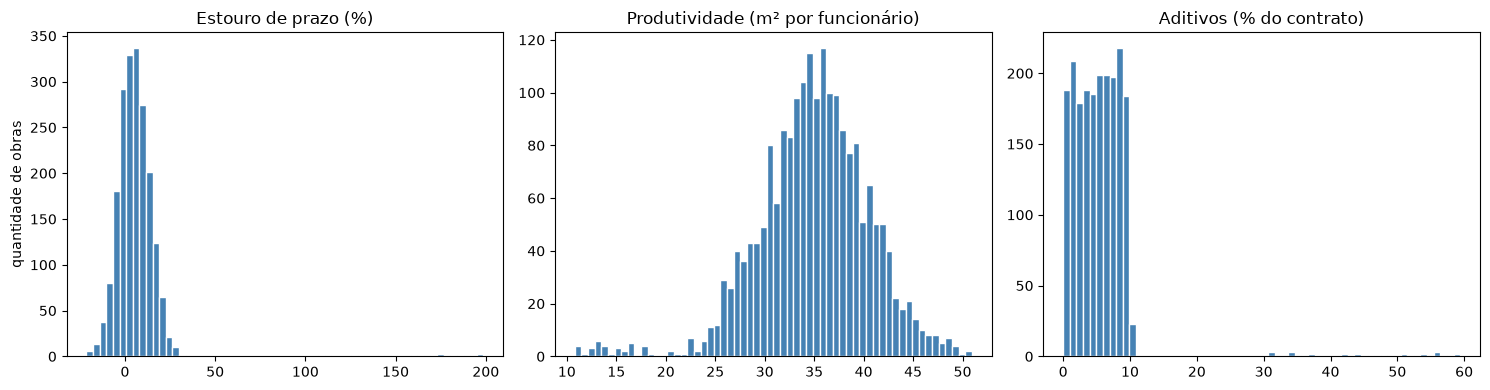

In [ ]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

eixos[0].hist(df["estouro_prazo_pct"], bins=60, color="steelblue", edgecolor="white")
eixos[0].set_title("Estouro de prazo (%)")
eixos[0].set_ylabel("quantidade de obras")

eixos[1].hist(df["m2_por_funcionario"]w, bins=60, color="steelblue", edgecolor="white")
eixos[1].set_title("Produtividade (m² por funcionário)")

eixos[2].hist(df["pct_aditivos"], bins=60, color="steelblue", edgecolor="white")
eixos[2].set_title("Aditivos (% do contrato)")

plt.tight_layout()
plt.show()

In [4]:
# Salva a base processada, que alimenta os detectores da próxima etapa
df.to_csv(os.path.join(RAIZ, "data", "processed", "obras_features.csv"), index=False)
print("Salvo em data/processed/obras_features.csv")

Salvo em data/processed/obras_features.csv


In [5]:
gabarito = pd.read_csv(os.path.join(RAIZ, "data", "raw", "obras_gabarito.csv"))[["id_obra", "anomalia"]]
df_avaliacao = df.merge(gabarito, on="id_obra")

df_avaliacao.groupby("anomalia")[
    ["custo_por_m2", "pct_aditivos", "m2_por_funcionario", "estouro_prazo_pct"]
].median().round(1)


,custo_por_m2,pct_aditivos,m2_por_funcionario,estouro_prazo_pct
anomalia,,,,
aditivos_excessivos,"5,729.80",46.00,34.50,5.10
custo_inflado,"5,907.30",5.10,35.00,4.40
nenhuma,"3,821.50",5.20,35.20,4.70
prazo_estourado,"4,055.10",4.40,33.60,171.60
produtividade_baixa,"6,253.20",4.30,14.10,7.60
